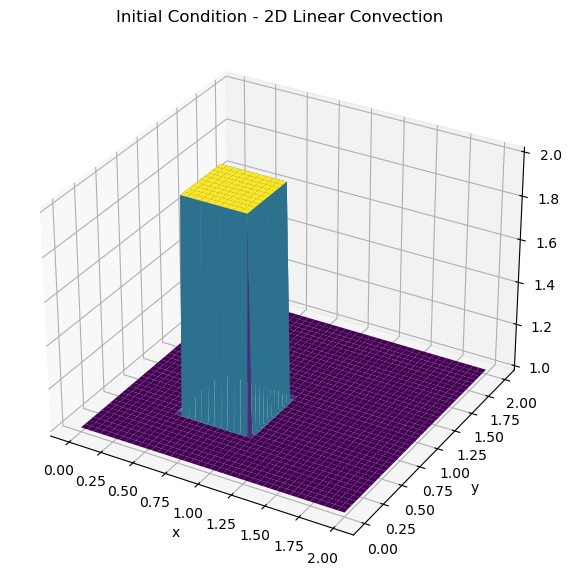

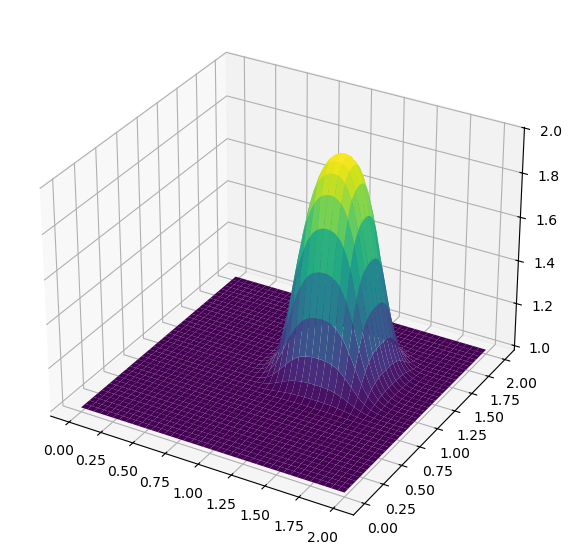

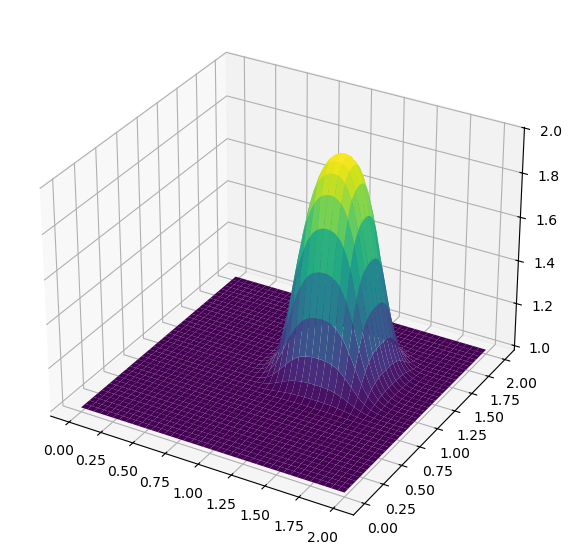

In [12]:
# 2-D Linear Convection

from mpl_toolkits.mplot3d import Axes3D

import numpy
from matplotlib import pyplot, cm

nx = 81
ny = 81
nt = 100
c = 1
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = 0.2
dt = sigma * dx

x = numpy.linspace(0, 2, nx)
y = numpy.linspace(0, 2, ny)

u = numpy.ones((ny, nx))       # 行数=ny（y方向点数），列数=nx（x方向点数）
un = numpy.ones((ny, nx))

###Assign initial conditions

u[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 /dx + 1)] =2

fig, ax = pyplot.subplots(figsize=(11, 7), dpi=100, subplot_kw=dict(projection='3d'))
X, Y = numpy.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u, cmap=cm.viridis)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title('Initial Condition - 2D Linear Convection')

# -------------------------Iterating in two dimensions 使用for循环

u = numpy.ones((ny, nx))
u[int(.5 / dy):int(1 / dy + 1), int(.5 / dx):int(1 / dx + 1)] = 2

for n in range(nt + 1): ##loop across number of time steps
    un = u.copy()
    row, col = u.shape
    for j in range(1, row):
        for i in range(1, col):
            u[j, i] = (un[j, i] - (c * dt / dx * (un[j, i] - un[j, i - 1])) -
                                  (c * dt / dy * (un[j, i] - un[j - 1, i])))
            u[0, :] = 1
            u[-1, :] = 1
            u[:, 0] = 1
            u[:, -1] = 1

fig, ax = pyplot.subplots(figsize=(11, 7), dpi=100, subplot_kw=dict(projection='3d'))
X, Y = numpy.meshgrid(x, y)
surf2 = ax.plot_surface(X, Y, u, cmap=cm.viridis)

# ----------------Iterating in two dimensions        使用数组操作

u = numpy.ones((ny, nx))
u[int(.5 / dy):int(1 / dy + 1), int(.5 / dx):int(1 / dx + 1)] = 2

for n in range(nt + 1): ##loop across number of time steps
    un = u.copy()
    u[1:, 1:] = (un[1:, 1:] - (c * dt / dx * (un[1:, 1:] - un[1:, :-1])) -
                              (c * dt / dy * (un[1:, 1:] - un[:-1, 1:])))
    u[0, :] = 1        #  下边界(y=0处)全部设置为 1  u[j, i]
    u[-1, :] = 1       # 上     
    u[:, 0] = 1        # 左
    u[:, -1] = 1       # 右

fig, ax = pyplot.subplots(figsize=(11, 7), dpi=100, subplot_kw=dict(projection='3d'))
X, Y = numpy.meshgrid(x, y)
surf3 = ax.plot_surface(X, Y, u, cmap=cm.viridis)
